Загрузка данных с Binance...
  ✓ BTCUSDT  (2922 дней)
  ✓ ETHUSDT  (2922 дней)
  ✓ XRPUSDT  (2799 дней)
  ✓ BCHUSDT  (2226 дней)
  ✓ LTCUSDT  (2922 дней)
  ✓ ADAUSDT  (2816 дней)
  ✓ XLMUSDT  (2772 дней)
  ✓ EOSUSDT  (2556 дней)
  ✓ NEOUSDT  (2922 дней)
  ✓ XMRUSDT  (1804 дней)
  ✓ DASHUSDT  (2471 дней)
  ✓ IOTAUSDT  (2772 дней)
  ✓ QTUMUSDT  (2845 дней)
  ✓ BNBUSDT  (2922 дней)
  ✓ ZECUSDT  (2478 дней)
  ✓ ETCUSDT  (2760 дней)
  ✓ OMGUSDT  (1903 дней)
  ✓ TRXUSDT  (2761 дней)
  ✓ ICXUSDT  (2759 дней)
  ✓ XEMUSDT  (1302 дней)

Выборка: 2020-11-25 — 2024-02-20
Активов: 20, наблюдений на актив: ~1183


C:\Users\Mary Ruth\AppData\Local\Temp\ipykernel_8580\1642005642.py:138: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


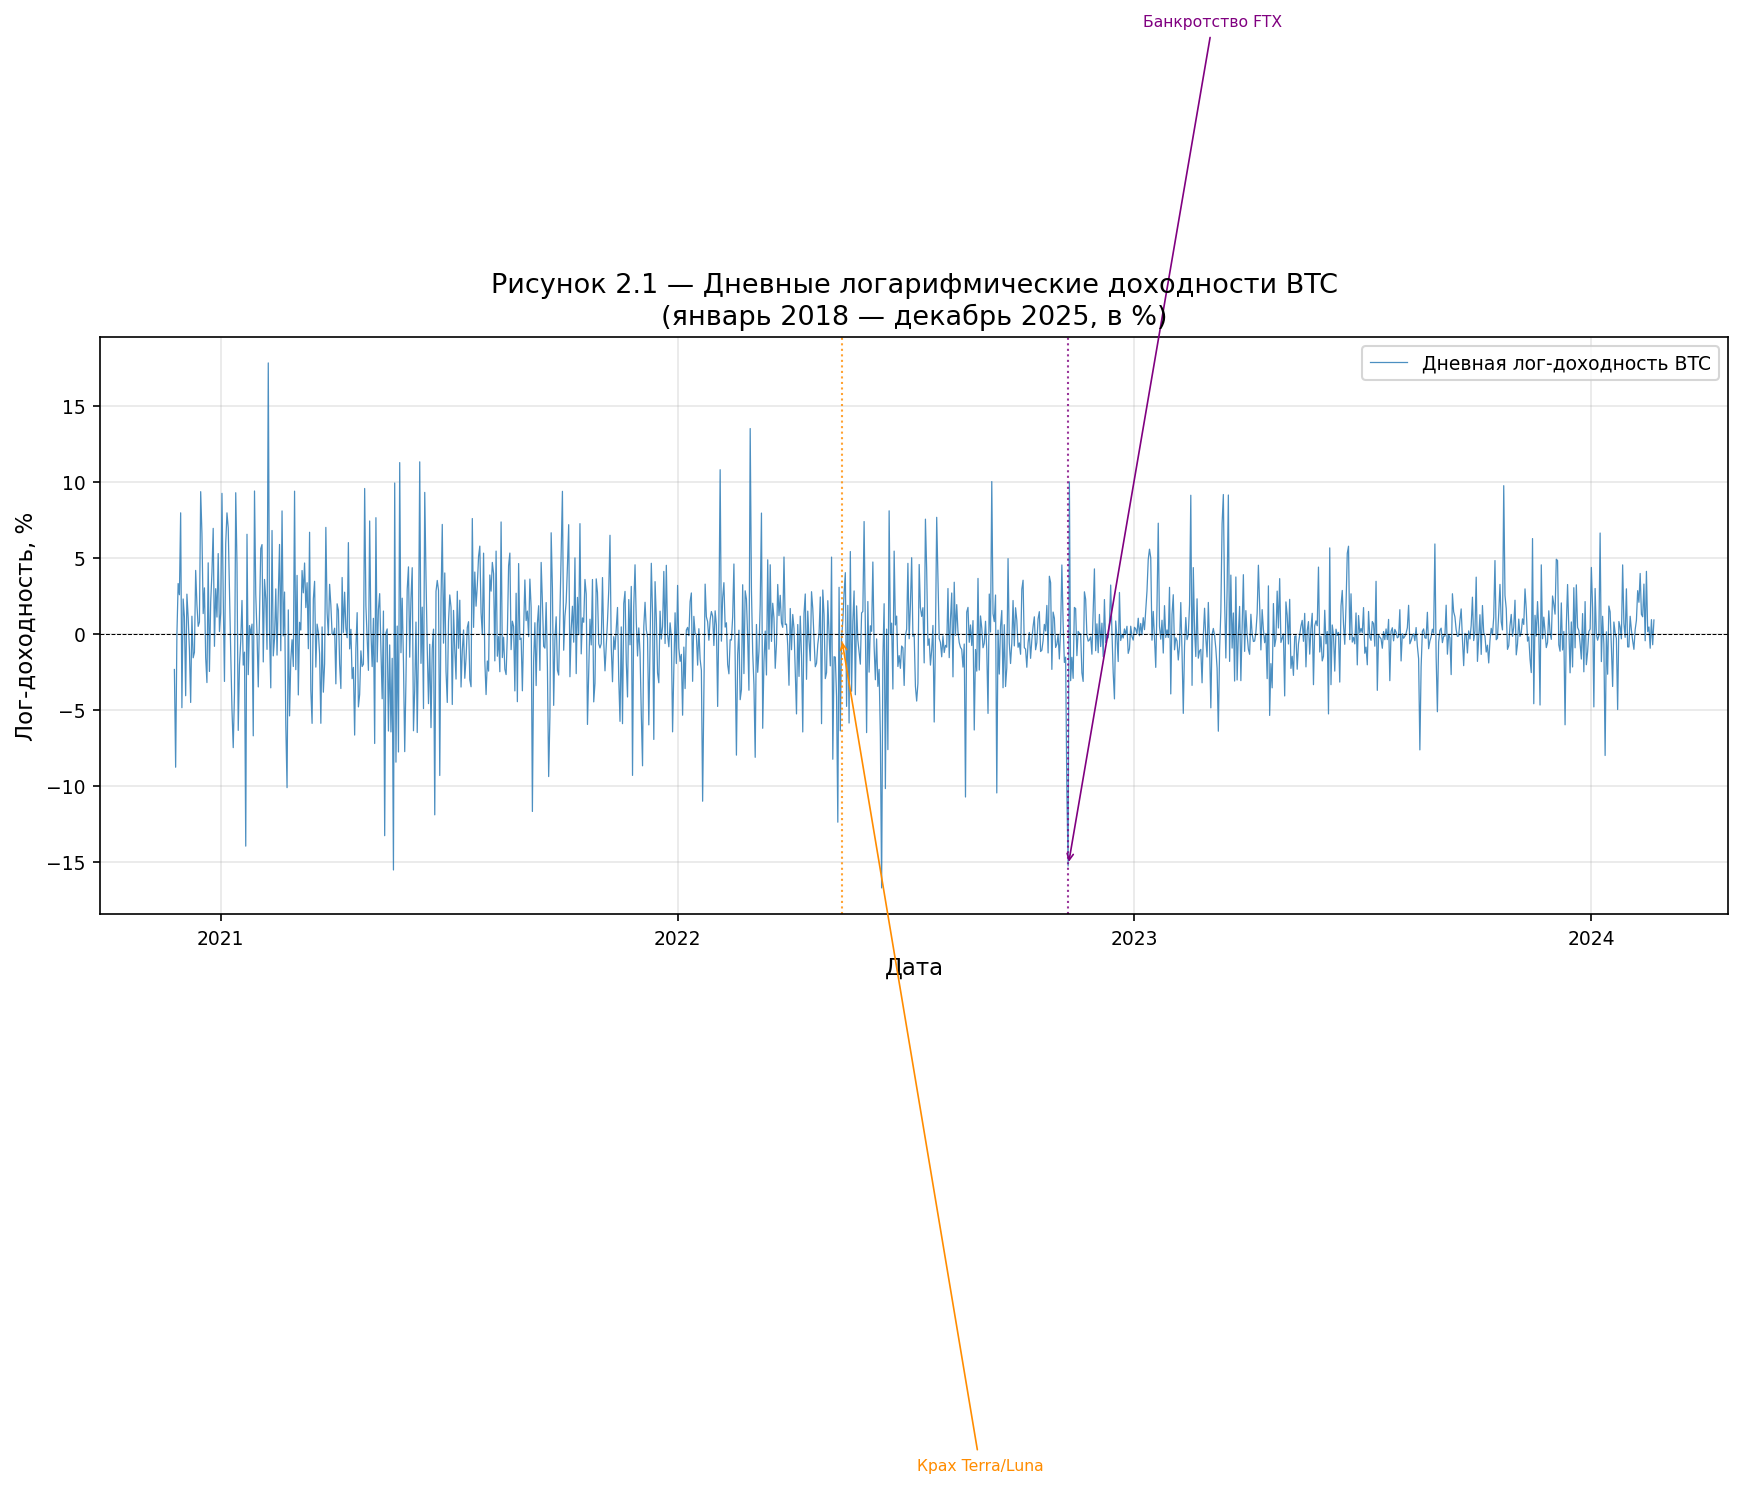

✓ Рисунок 2.1 сохранён


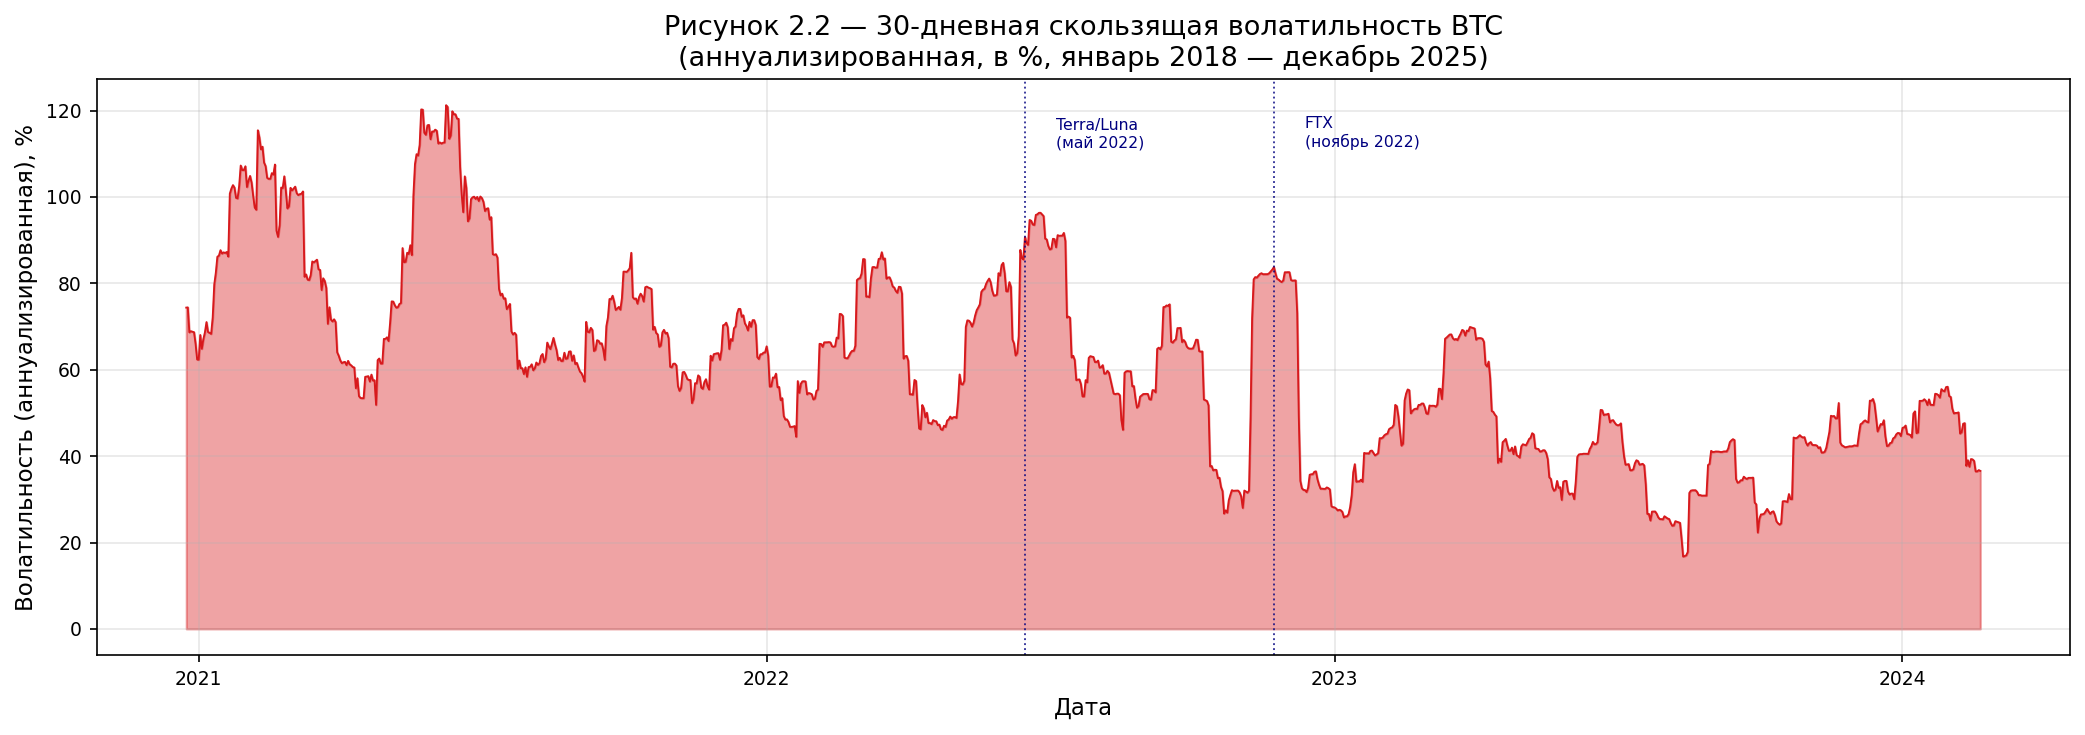

✓ Рисунок 2.2 сохранён


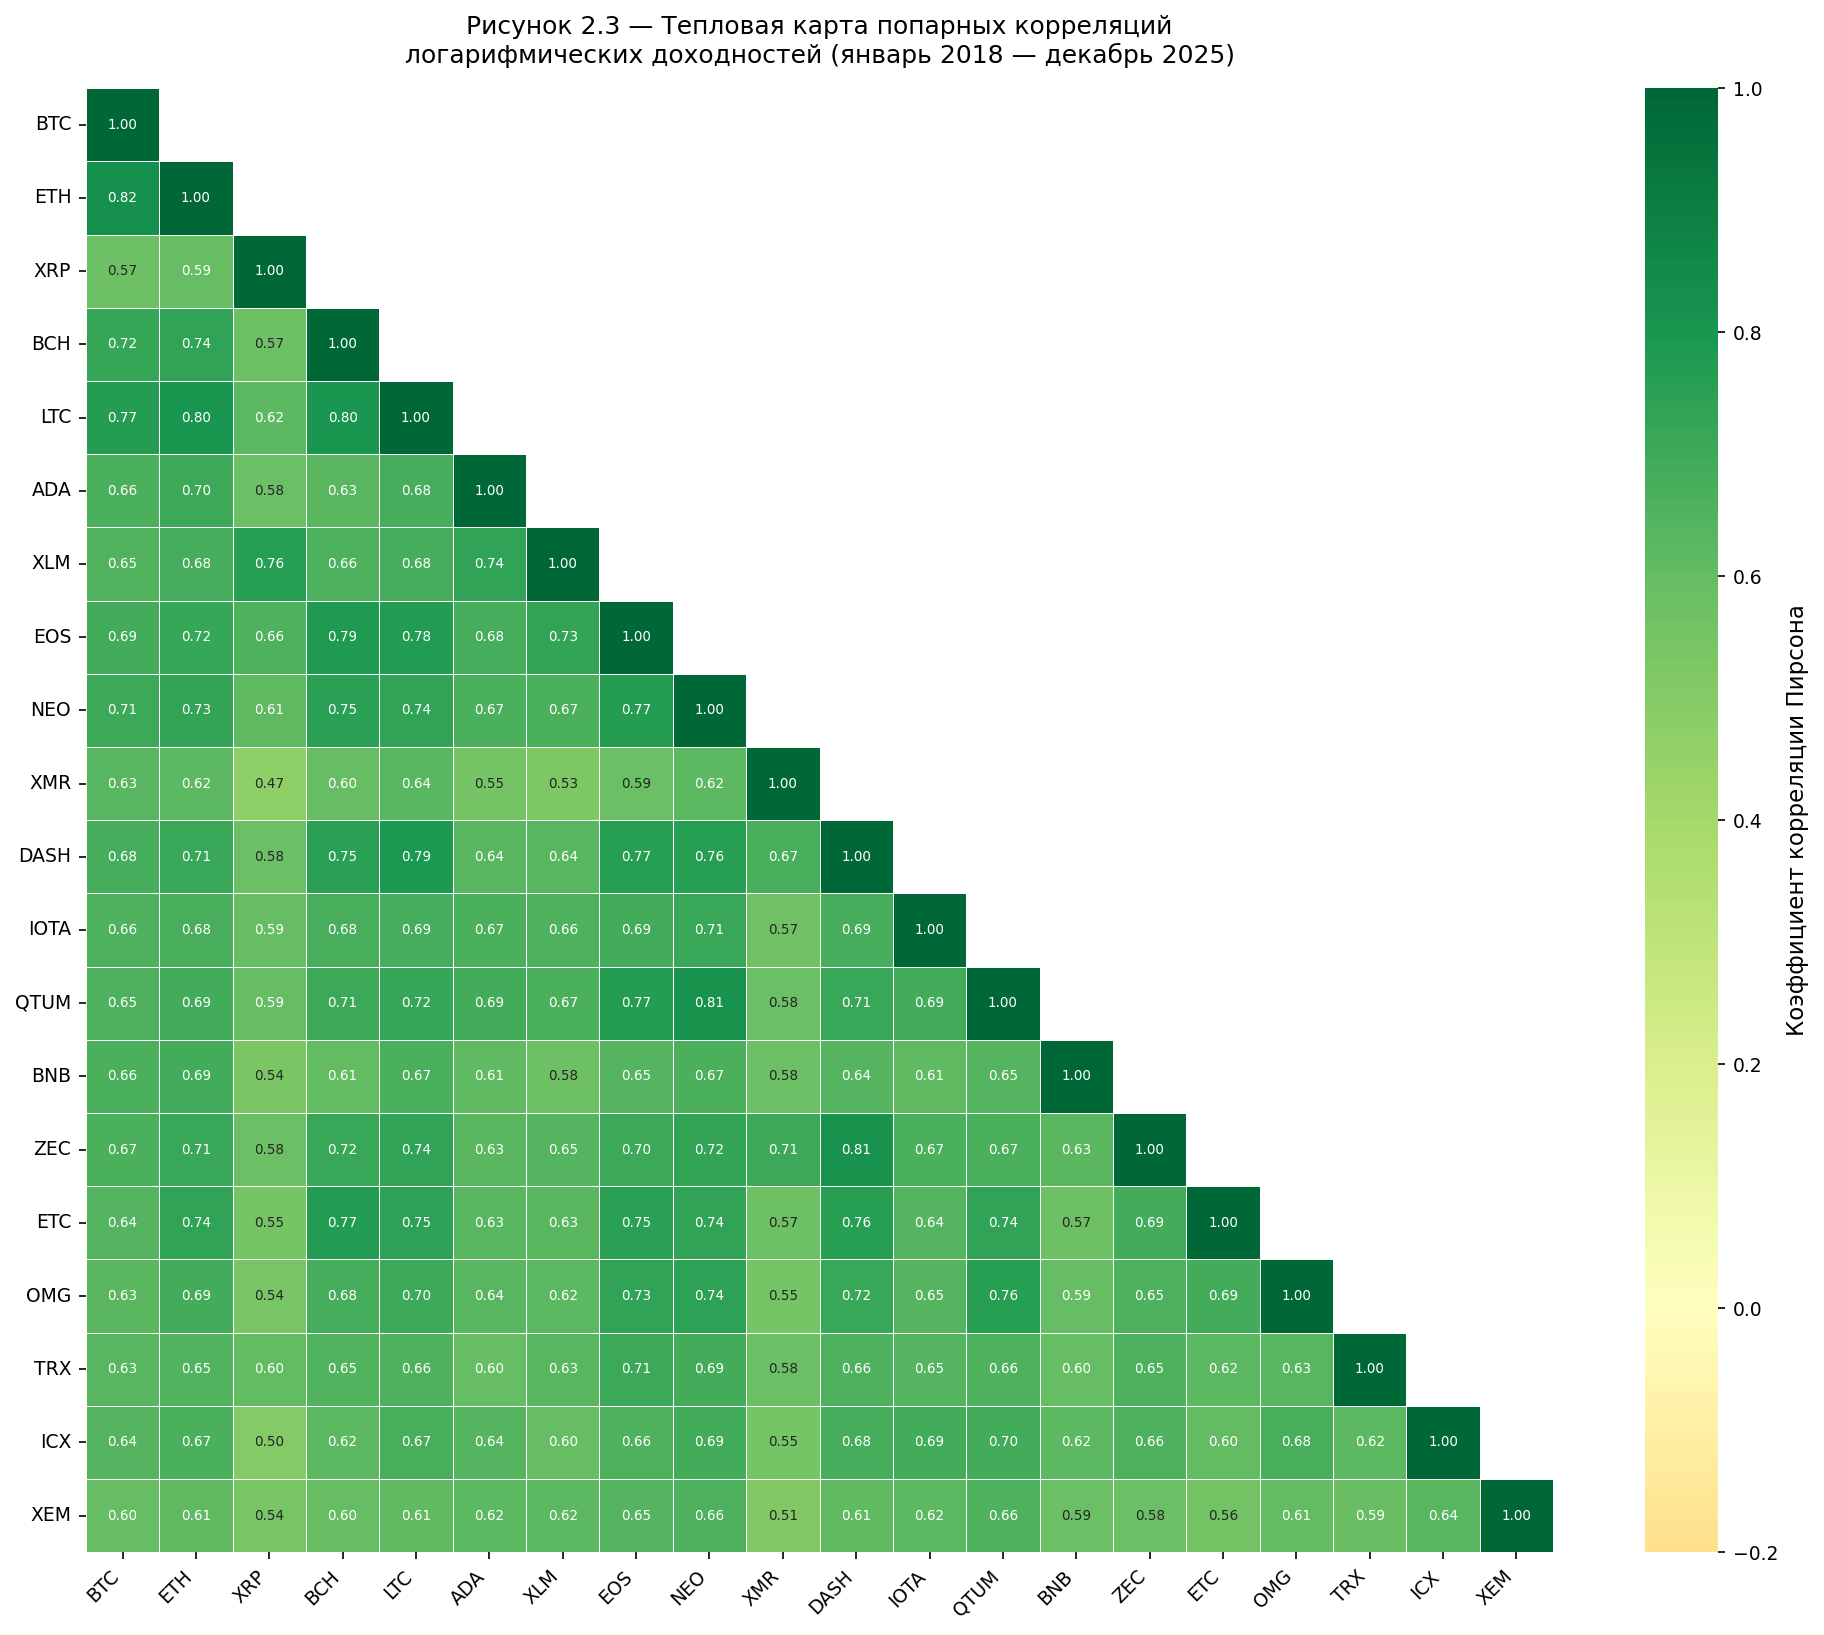

✓ Рисунок 2.3 сохранён

Считаем Таблицу 5...

ТАБЛИЦА 5:
Актив  Среднее, %  Std, %  Min, %  Max, %  Асимметрия  Экс. эксцесс p (ЖБ) p (ЛБ) p (ARCH)
  BTC      0.0848  3.3780  -16.70   17.84      -0.183         3.375 <0.001 <0.001   <0.001
  ETH      0.1358  4.3957  -32.49   23.38      -0.405         5.521 <0.001 <0.001   <0.001
  XRP     -0.0178  5.9537  -53.87   54.87       0.571        19.647 <0.001 <0.001   <0.001
  BCH     -0.0230  5.2692  -45.01   42.43       0.260        12.183 <0.001 <0.001   <0.001
  LTC     -0.0210  4.9402  -45.81   26.35      -0.794         9.008 <0.001 <0.001   <0.001
  ADA      0.1110  5.2236  -31.22   28.64       0.367         4.127 <0.001 <0.001   <0.001
  XLM     -0.0431  5.3086  -37.60   56.49       1.322        20.321 <0.001  0.003    0.013
  EOS     -0.1273  5.6573  -49.45   44.88      -0.383        12.055 <0.001 <0.001   <0.001
  NEO     -0.0403  5.6491  -46.12   34.21      -0.597         7.794 <0.001 <0.001   <0.001
  XMR     -0.0110  4.8903  -54.70

ModuleNotFoundError: No module named 'openpyxl'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import time
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller

# ============================================================
# ПАРАМЕТРЫ
# ============================================================

# Топ-20 по капитализации на 01.01.2018
SYMBOLS = [
    'BTCUSDT', 'ETHUSDT', 'XRPUSDT', 'BCHUSDT', 'LTCUSDT',
    'ADAUSDT', 'XLMUSDT', 'EOSUSDT', 'NEOUSDT', 'XMRUSDT',
    'DASHUSDT', 'IOTAUSDT', 'QTUMUSDT', 'BNBUSDT', 'ZECUSDT',
    'ETCUSDT', 'OMGUSDT', 'TRXUSDT', 'ICXUSDT', 'XEMUSDT'
]

LABELS = [s.replace('USDT', '') for s in SYMBOLS]

START_DATE = '2018-01-01'
END_DATE   = '2025-12-31'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150
})

# ============================================================
# 1. ЗАГРУЗКА ДАННЫХ С BINANCE
# ============================================================

def fetch_binance_klines(symbol, interval='1d',
                          start='2018-01-01', end='2025-12-31'):
    url = 'https://api.binance.com/api/v3/klines'
    start_ms = int(pd.Timestamp(start).timestamp() * 1000)
    end_ms   = int(pd.Timestamp(end).timestamp()   * 1000)
    all_rows = []
    while start_ms < end_ms:
        params = {
            'symbol':    symbol,
            'interval':  interval,
            'startTime': start_ms,
            'endTime':   end_ms,
            'limit':     1000
        }
        r = requests.get(url, params=params, timeout=15)
        data = r.json()
        if not data or isinstance(data, dict):
            break
        all_rows.extend(data)
        start_ms = data[-1][0] + 1
        time.sleep(0.15)
    if not all_rows:
        return None
    df = pd.DataFrame(all_rows, columns=[
        'open_time','open','high','low','close','volume',
        'close_time','quote_vol','trades',
        'taker_buy_base','taker_buy_quote','ignore'
    ])
    df['date']  = pd.to_datetime(df['open_time'], unit='ms')
    df['close'] = df['close'].astype(float)
    df['volume']= df['volume'].astype(float)
    df = df[df['close'] > 0]   # убираем технические нули
    return df.set_index('date')['close']

print("Загрузка данных с Binance...")
closes = {}
for sym in SYMBOLS:
    try:
        s = fetch_binance_klines(sym)
        if s is not None and len(s) > 100:
            closes[sym] = s
            print(f"  ✓ {sym}  ({len(s)} дней)")
        else:
            print(f"  ✗ {sym}  — данных недостаточно")
    except Exception as e:
        print(f"  ✗ {sym}  — ошибка: {e}")

closes_df = pd.DataFrame(closes).sort_index()
closes_df = closes_df.loc[START_DATE:END_DATE]

# Логарифмические доходности (без IQR-фильтра!)
returns = np.log(closes_df / closes_df.shift(1)).dropna()

print(f"\nВыборка: {returns.index[0].date()} — {returns.index[-1].date()}")
print(f"Активов: {returns.shape[1]}, наблюдений на актив: ~{len(returns)}")

# ============================================================
# 2. РИСУНОК 2.1 — ДНЕВНЫЕ ЛОГ-ДОХОДНОСТИ BTC
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

btc = returns['BTCUSDT'] if 'BTCUSDT' in returns.columns else returns.iloc[:, 0]
btc_label = 'BTC'

ax.plot(btc.index, btc.values * 100, color='#2c7bb6',
        linewidth=0.6, alpha=0.85, label='Дневная лог-доходность BTC')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

# Отмечаем ключевые события
events = {
    '2020-03-12': ('COVID-крах\n−37%',   'red',   -45),
    '2022-05-12': ('Крах Terra/Luna',     'darkorange', -55),
    '2022-11-09': ('Банкротство FTX',     'purple', 40),
}
for date_str, (label, color, y_offset) in events.items():
    d = pd.Timestamp(date_str)
    if d in btc.index:
        val = btc[d] * 100
        ax.axvline(d, color=color, linewidth=1.0,
                   linestyle=':', alpha=0.8)
        ax.annotate(label, xy=(d, val),
                    xytext=(d + pd.Timedelta(days=60), y_offset),
                    fontsize=7.5, color=color,
                    arrowprops=dict(arrowstyle='->', color=color,
                                   lw=0.8))

ax.set_title('Рисунок 2.1 — Дневные логарифмические доходности BTC\n'
             '(январь 2018 — декабрь 2025, в %)')
ax.set_xlabel('Дата')
ax.set_ylabel('Лог-доходность, %')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_2_1_log_returns.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Рисунок 2.1 сохранён")

# ============================================================
# 3. РИСУНОК 2.2 — 30-ДНЕВНАЯ СКОЛЬЗЯЩАЯ ВОЛАТИЛЬНОСТЬ BTC
# ============================================================

vol_30 = btc.rolling(30).std() * np.sqrt(365) * 100  # annualized %

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(vol_30.index, vol_30.values,
                alpha=0.4, color='#d7191c')
ax.plot(vol_30.index, vol_30.values,
        color='#d7191c', linewidth=0.9)

# Ключевые пики
for date_str, label in [
    ('2020-03-20', 'COVID\n(март 2020)'),
    ('2022-06-01', 'Terra/Luna\n(май 2022)'),
    ('2022-11-15', 'FTX\n(ноябрь 2022)'),
]:
    d = pd.Timestamp(date_str)
    near = vol_30.loc[d - pd.Timedelta(days=15):
                      d + pd.Timedelta(days=15)]
    if len(near):
        peak_d = near.idxmax()
        ax.axvline(peak_d, color='navy',
                   linewidth=0.9, linestyle=':', alpha=0.8)
        ax.text(peak_d + pd.Timedelta(days=20),
                vol_30.max() * 0.92,
                label, fontsize=7.5, color='navy')

ax.set_title('Рисунок 2.2 — 30-дневная скользящая волатильность BTC\n'
             '(аннуализированная, в %, январь 2018 — декабрь 2025)')
ax.set_xlabel('Дата')
ax.set_ylabel('Волатильность (аннуализированная), %')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_2_2_volatility.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Рисунок 2.2 сохранён")

# ============================================================
# 4. РИСУНОК 2.3 — ТЕПЛОВАЯ КАРТА КОРРЕЛЯЦИЙ 20×20
# ============================================================

corr = returns.corr()
tick_labels = [s.replace('USDT','') for s in corr.columns]

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # верхний треугольник

sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 6.5},
    cmap='RdYlGn', center=0, vmin=-0.2, vmax=1.0,
    linewidths=0.3, linecolor='white',
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    ax=ax,
    cbar_kws={'label': 'Коэффициент корреляции Пирсона'}
)
ax.set_title(
    'Рисунок 2.3 — Тепловая карта попарных корреляций\n'
    'логарифмических доходностей (январь 2018 — декабрь 2025)',
    fontsize=12, pad=12
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_2_3_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Рисунок 2.3 сохранён")

# ============================================================
# 5. ТАБЛИЦА 5 — ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ + ТЕСТЫ
# ============================================================

print("\nСчитаем Таблицу 5...")
rows = []
for sym in returns.columns:
    r = returns[sym].dropna()
    label = sym.replace('USDT', '')

    mean_  = r.mean() * 100
    std_   = r.std()  * 100
    min_   = r.min()  * 100
    max_   = r.max()  * 100
    skew_  = stats.skew(r)
    kurt_  = stats.kurtosis(r)          # excess kurtosis

    # Тест Жарка–Бера
    _, jb_p  = stats.jarque_bera(r)

    # Тест Льюнга–Бокса (лаги 1–10, по квадратам)
    lb = acorr_ljungbox(r**2, lags=[10], return_df=True)
    lb_p = float(lb['lb_pvalue'].values[0])

    # ARCH-LM тест (лаг 10)
    try:
        _, arch_p, _, _ = het_arch(r, nlags=10)
    except:
        arch_p = np.nan

    rows.append({
        'Актив':        label,
        'Среднее, %':   round(mean_, 4),
        'Std, %':       round(std_,  4),
        'Min, %':       round(min_,  2),
        'Max, %':       round(max_,  2),
        'Асимметрия':   round(skew_, 3),
        'Экс. эксцесс': round(kurt_, 3),
        'p (ЖБ)':       f"{'<0.001' if jb_p<0.001 else round(jb_p,3)}",
        'p (ЛБ)':       f"{'<0.001' if lb_p<0.001 else round(lb_p,3)}",
        'p (ARCH)':     f"{'<0.001' if (arch_p is not None and arch_p<0.001) else (round(arch_p,3) if arch_p is not None else 'N/A')}",
    })

table5 = pd.DataFrame(rows)
print("\nТАБЛИЦА 5:")
print(table5.to_string(index=False))
table5.to_excel('table_5_descriptive_stats.xlsx', index=False)
print("\n✓ Таблица 5 сохранена в table_5_descriptive_stats.xlsx")

# ============================================================
# 6. СПИСОК 20 АКТИВОВ ДЛЯ § 2.1
# ============================================================

print("\n--- СПИСОК АКТИВОВ ДЛЯ § 2.1 ---")
for i, sym in enumerate(SYMBOLS, 1):
    has_data = sym in returns.columns
    n_obs = len(returns[sym].dropna()) if has_data else 0
    print(f"{i:2}. {sym.replace('USDT',''):8} | наблюдений: {n_obs}")

In [4]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Шаг 1 — установить openpyxl
import sys
!{sys.executable} -m pip install openpyxl

# Шаг 2 — сохранить таблицу
table5.to_excel('table_5_descriptive_stats.xlsx', index=False)
print("✓ Таблица 5 сохранена")

"C:\Users\Mary" ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.


✓ Таблица 5 сохранена


In [6]:
# Шаг 1 — проверяем диапазон
print("Диапазон returns:")
print(f"  Начало: {returns.index[0].date()}")
print(f"  Конец:  {returns.index[-1].date()}")
print(f"  Строк:  {len(returns)}")
print(f"\nBTC первые наблюдения:\n{returns['BTCUSDT'].dropna().head()}")
print(f"\nBTC мин: {returns['BTCUSDT'].min()*100:.2f}%")
print(f"BTC макс: {returns['BTCUSDT'].max()*100:.2f}%")

Диапазон returns:
  Начало: 2020-11-25
  Конец:  2024-02-20
  Строк:  1183

BTC первые наблюдения:
date
2020-11-25   -0.023280
2020-11-26   -0.087578
2020-11-27   -0.000580
2020-11-28    0.033299
2020-11-29    0.025911
Freq: D, Name: BTCUSDT, dtype: float64

BTC мин: -16.70%
BTC макс: 17.84%


In [7]:
# Пересчитываем returns правильно — без обрезки по общей дате
returns = np.log(closes_df / closes_df.shift(1))
# НЕ используем dropna() — каждый актив имеет NaN там где нет данных

print(f"Диапазон: {returns.index[0].date()} — {returns.index[-1].date()}")
print(f"Строк: {len(returns)}")
print(f"BTC начало: {returns['BTCUSDT'].dropna().index[0].date()}")
print(f"BTC мин: {returns['BTCUSDT'].dropna().min()*100:.2f}%")
print(f"BTC макс: {returns['BTCUSDT'].dropna().max()*100:.2f}%")

# Пересчитываем Таблицу 5 (per-asset dropna)
rows = []
for sym in returns.columns:
    r = returns[sym].dropna()  # каждый актив считается по своим данным
    label = sym.replace('USDT', '')
    mean_  = r.mean() * 100
    std_   = r.std()  * 100
    min_   = r.min()  * 100
    max_   = r.max()  * 100
    skew_  = stats.skew(r)
    kurt_  = stats.kurtosis(r)
    _, jb_p = stats.jarque_bera(r)
    lb = acorr_ljungbox(r**2, lags=[10], return_df=True)
    lb_p = float(lb['lb_pvalue'].values[0])
    try:
        _, arch_p, _, _ = het_arch(r, nlags=10)
    except:
        arch_p = np.nan
    rows.append({
        'Актив':        label,
        'Среднее, %':   round(mean_, 4),
        'Std, %':       round(std_,  4),
        'Min, %':       round(min_,  2),
        'Max, %':       round(max_,  2),
        'Асимметрия':   round(skew_, 3),
        'Экс. эксцесс': round(kurt_, 3),
        'p (ЖБ)':       f"{'<0.001' if jb_p<0.001 else round(jb_p,3)}",
        'p (ЛБ)':       f"{'<0.001' if lb_p<0.001 else round(lb_p,3)}",
        'p (ARCH)':     f"{'<0.001' if (arch_p is not None and arch_p<0.001) else (round(arch_p,3) if arch_p is not None else 'N/A')}",
    })

table5 = pd.DataFrame(rows)
print("\nТАБЛИЦА 5 (обновлённая):")
print(table5.to_string(index=False))

# Сохраняем
table5.to_csv('table_5_descriptive_stats.csv', index=False, encoding='utf-8-sig')
print("\n✓ Таблица 5 сохранена в CSV")

Диапазон: 2018-01-01 — 2025-12-31
Строк: 2922
BTC начало: 2018-01-02
BTC мин: -50.26%
BTC макс: 17.84%

ТАБЛИЦА 5 (обновлённая):
Актив  Среднее, %  Std, %  Min, %  Max, %  Асимметрия  Экс. эксцесс p (ЖБ) p (ЛБ) p (ARCH)
  BTC      0.0643  3.4851  -50.26   17.84      -1.149        17.798 <0.001 <0.001   <0.001
  ETH      0.0469  4.5843  -59.05   23.38      -0.955        12.772 <0.001 <0.001   <0.001
  XRP      0.0260  5.2465  -53.87   54.87       0.581        18.276 <0.001 <0.001   <0.001
  BCH      0.0456  5.1362  -61.65   46.01      -0.217        19.838 <0.001 <0.001   <0.001
  LTC     -0.0364  4.9079  -48.67   28.49      -0.605         8.997 <0.001 <0.001   <0.001
  ADA      0.0113  5.2826  -53.31   54.32       0.138        10.177 <0.001 <0.001   <0.001
  XLM     -0.0139  5.2016  -46.28   56.49       1.072        16.991 <0.001 <0.001   <0.001
  EOS     -0.1052  5.5311  -55.19   44.88      -0.641        11.322 <0.001 <0.001   <0.001
  NEO     -0.1063  5.6806  -50.24   36.90      -0.40

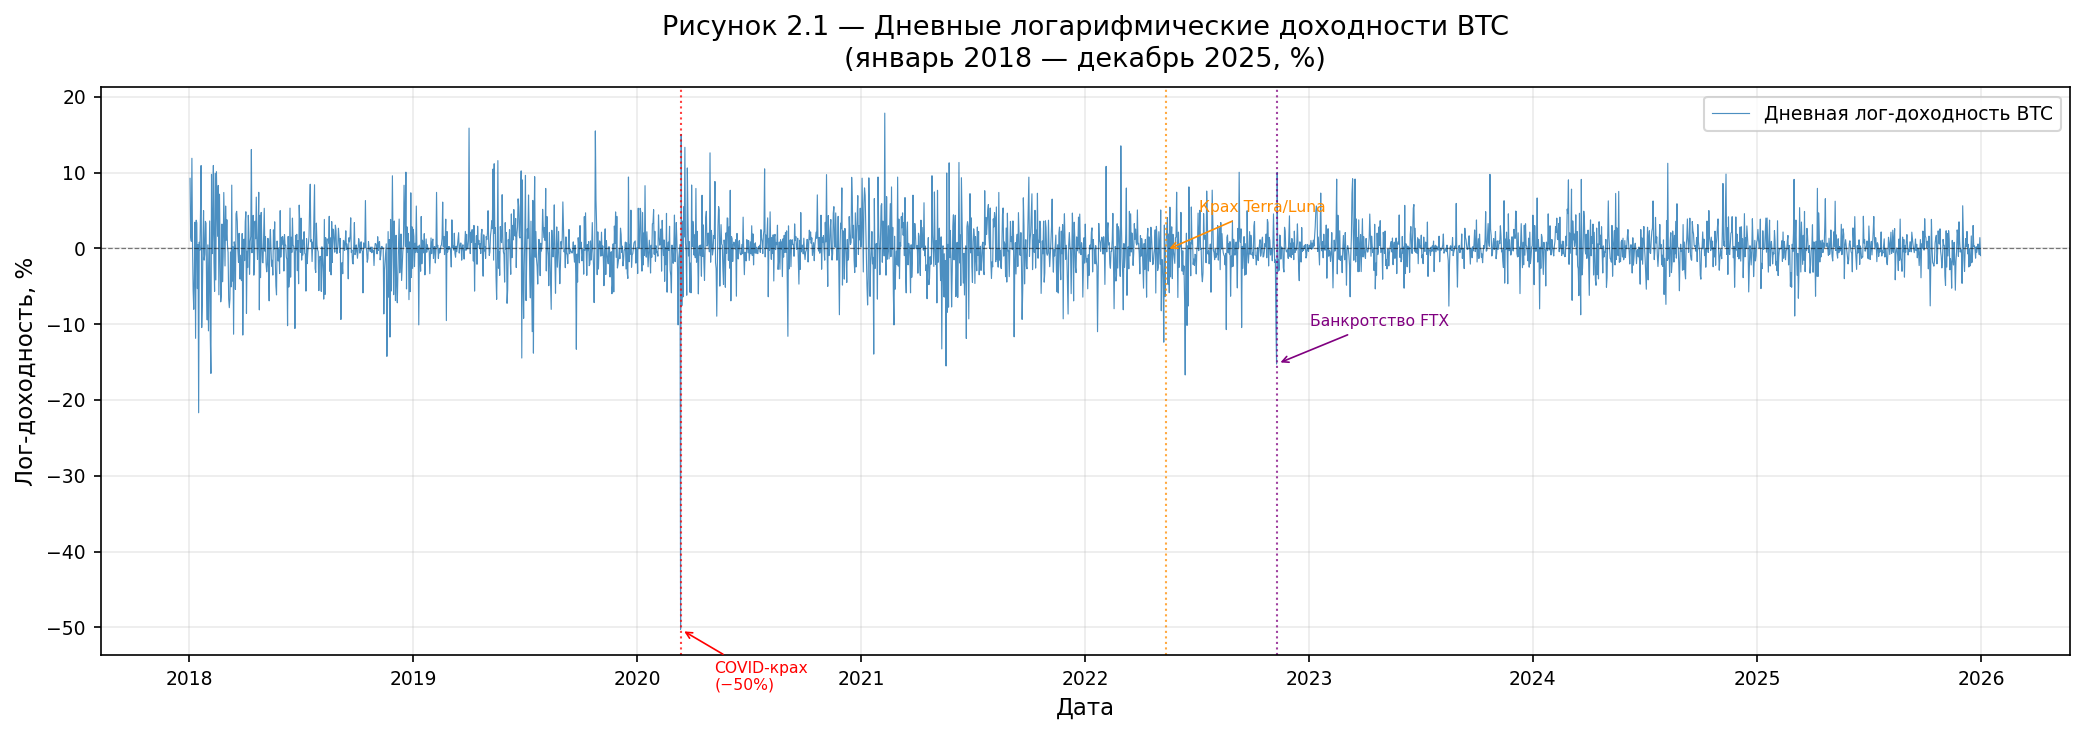

✓ Рисунок 2.1 сохранён


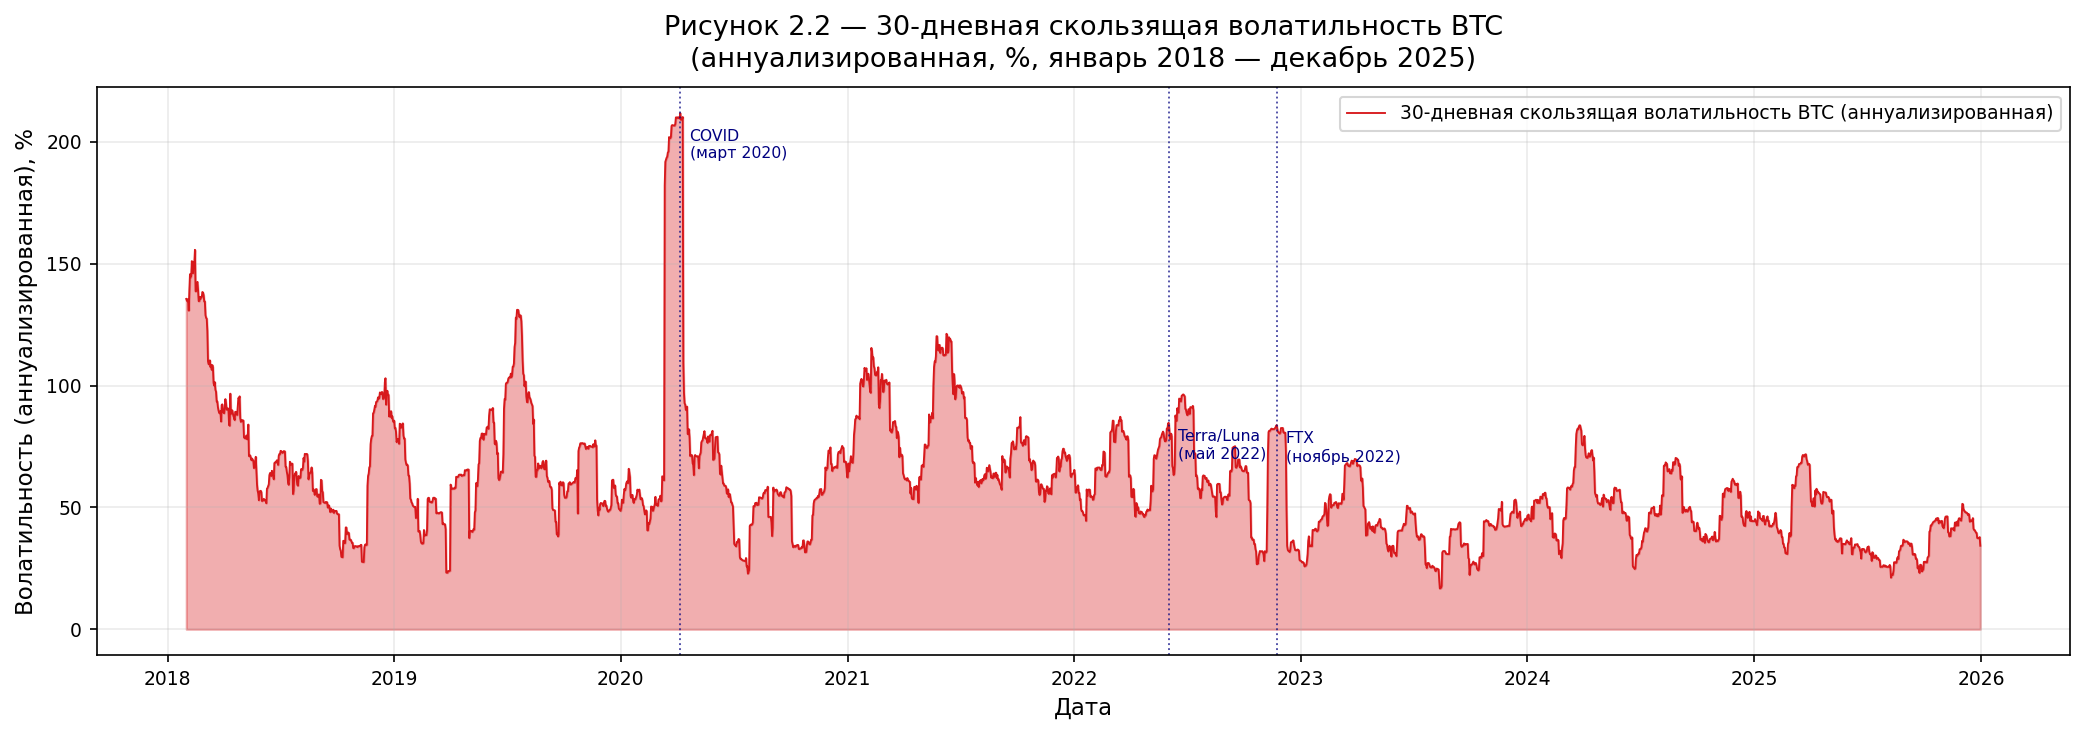

✓ Рисунок 2.2 сохранён


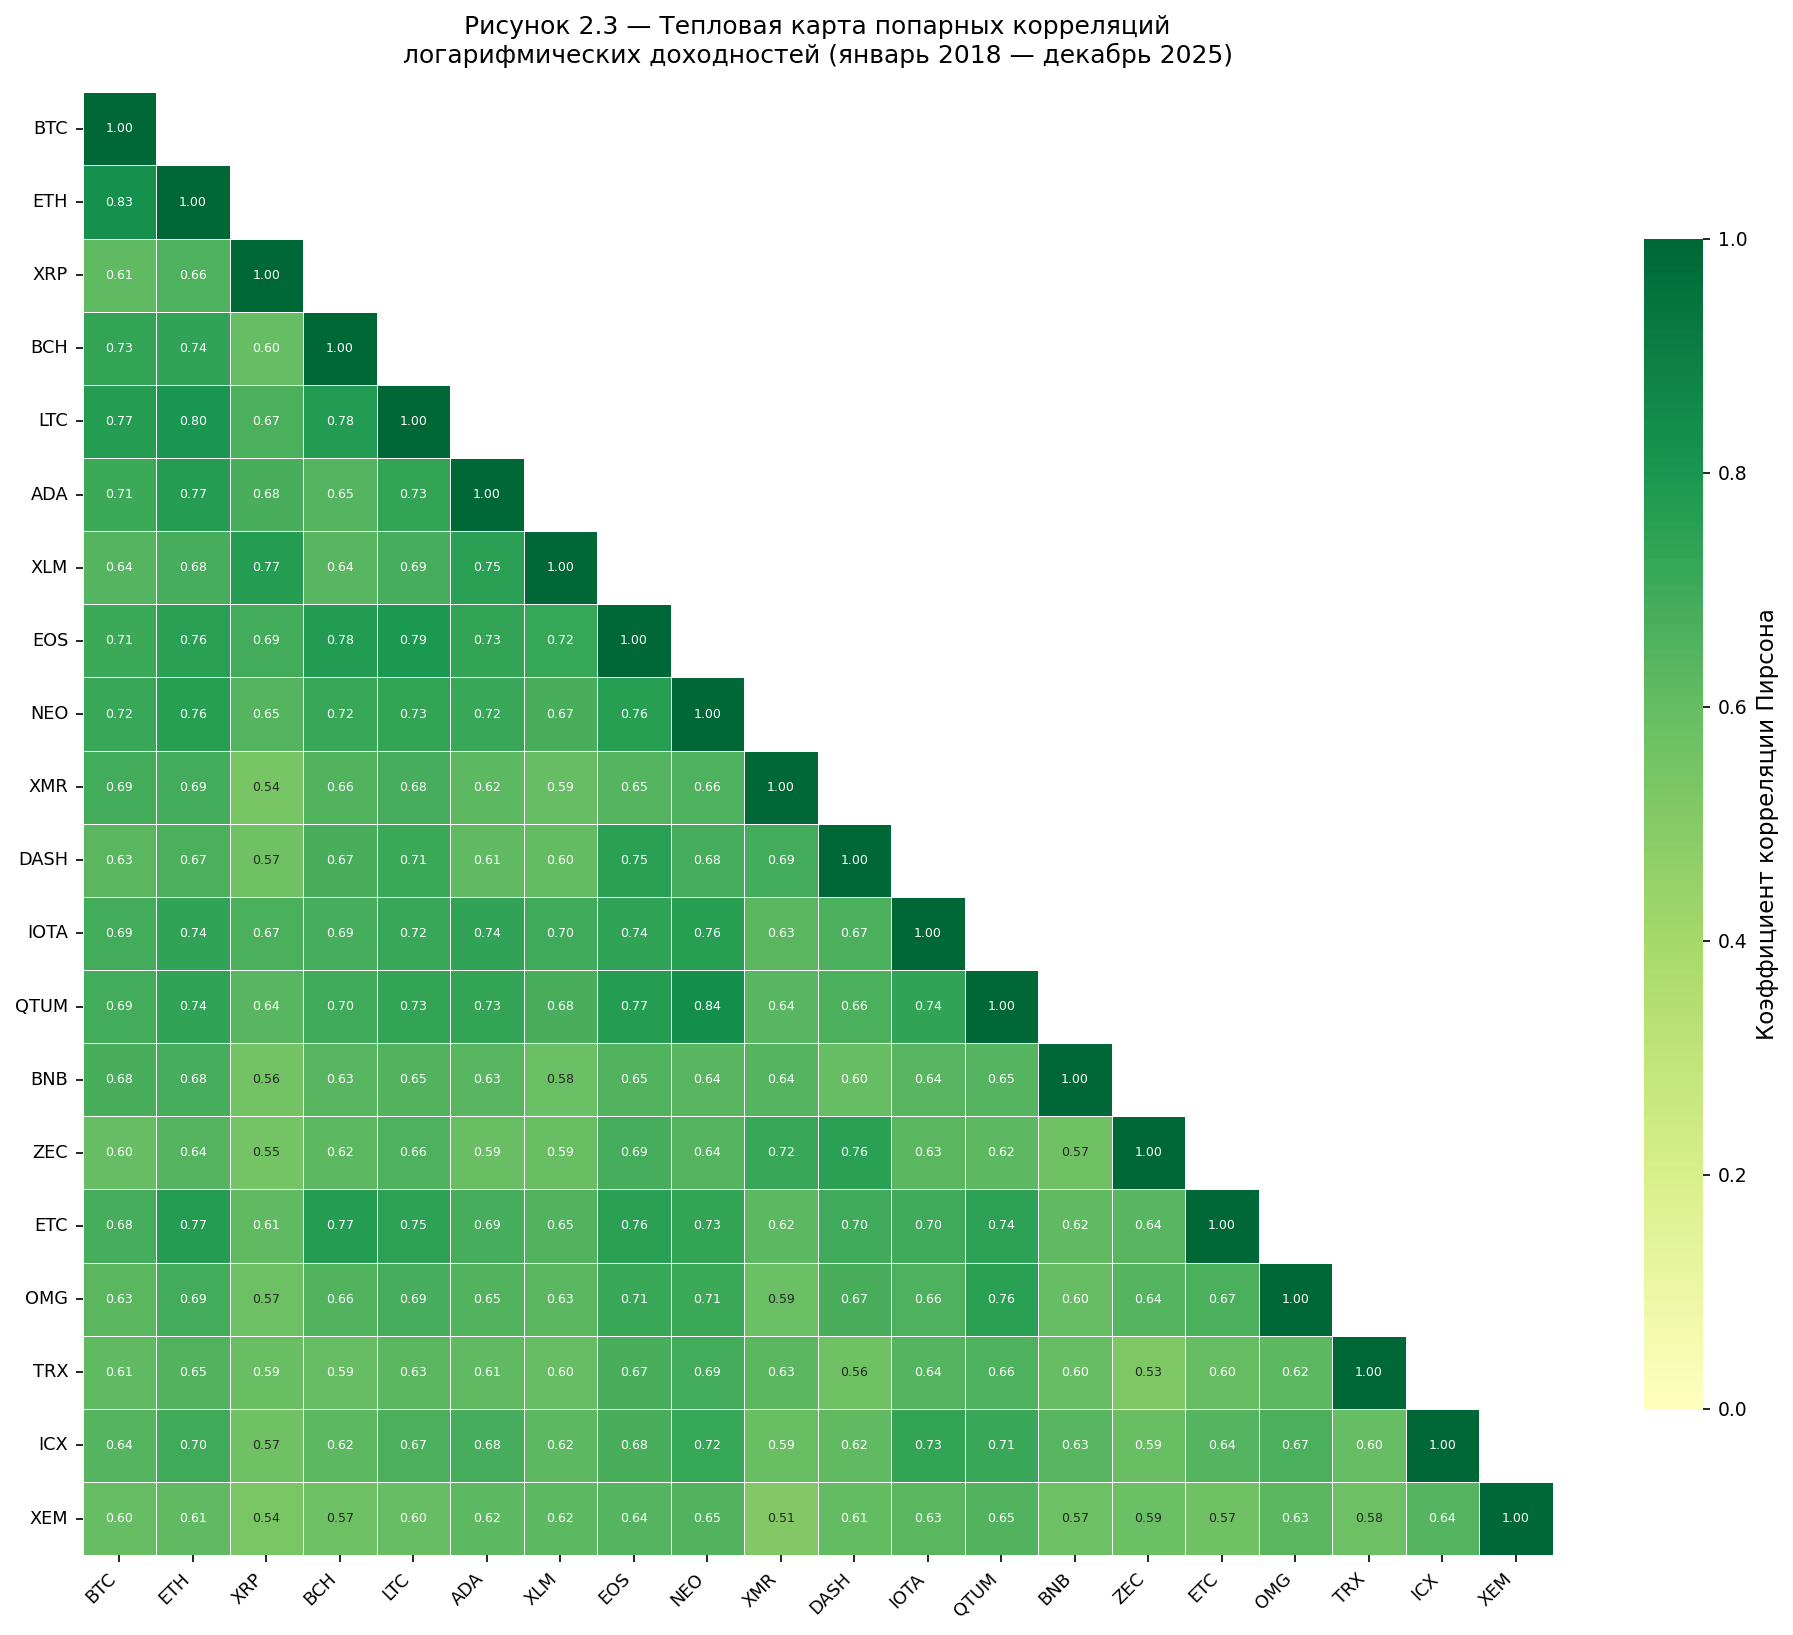

✓ Рисунок 2.3 сохранён

✅ Все три рисунка готовы!
   fig_2_1_log_returns.png
   fig_2_2_volatility.png
   fig_2_3_heatmap.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'axes.titlesize':  13,
    'axes.labelsize':  11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'figure.dpi':      150
})

# ============================================================
# РИСУНОК 2.1 — ДНЕВНЫЕ ЛОГ-ДОХОДНОСТИ BTC
# ============================================================

btc = returns['BTCUSDT'].dropna() * 100  # в процентах

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(btc.index, btc.values,
        color='#2c7bb6', linewidth=0.55,
        alpha=0.85, label='Дневная лог-доходность BTC')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)

# Ключевые события
events = {
    '2020-03-12': ('COVID-крах\n(−50%)',   'red',        'down'),
    '2022-05-12': ('Крах Terra/Luna',      'darkorange', 'up'),
    '2022-11-09': ('Банкротство FTX',      'purple',     'up'),
}

for date_str, (label, color, direction) in events.items():
    d = pd.Timestamp(date_str)
    # ищем ближайшую дату в индексе
    nearest = btc.index[btc.index.get_indexer([d], method='nearest')[0]]
    val = btc[nearest]
    ax.axvline(nearest, color=color, linewidth=1.0,
               linestyle=':', alpha=0.75)
    y_text = val - 8 if direction == 'down' else val + 5
    ax.annotate(
        label,
        xy=(nearest, val),
        xytext=(nearest + pd.Timedelta(days=55), y_text),
        fontsize=7.5, color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=0.8)
    )

ax.set_title(
    'Рисунок 2.1 — Дневные логарифмические доходности BTC\n'
    '(январь 2018 — декабрь 2025, %)',
    pad=10
)
ax.set_xlabel('Дата')
ax.set_ylabel('Лог-доходность, %')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('fig_2_1_log_returns.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Рисунок 2.1 сохранён")

# ============================================================
# РИСУНОК 2.2 — 30-ДНЕВНАЯ СКОЛЬЗЯЩАЯ ВОЛАТИЛЬНОСТЬ BTC
# ============================================================

# Аннуализированная волатильность в %
vol_30 = btc.rolling(30).std() * np.sqrt(365)
vol_30 = vol_30.dropna()

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(vol_30.index, vol_30.values,
                alpha=0.35, color='#d7191c')
ax.plot(vol_30.index, vol_30.values,
        color='#d7191c', linewidth=0.9,
        label='30-дневная скользящая волатильность BTC (аннуализированная)')

# Пики волатильности
peak_events = {
    '2020-03-20': 'COVID\n(март 2020)',
    '2022-05-20': 'Terra/Luna\n(май 2022)',
    '2022-11-15': 'FTX\n(ноябрь 2022)',
}

for date_str, label in peak_events.items():
    d = pd.Timestamp(date_str)
    window = vol_30.loc[
        d - pd.Timedelta(days=20):
        d + pd.Timedelta(days=20)
    ]
    if len(window) == 0:
        continue
    peak_d = window.idxmax()
    peak_v = window.max()
    ax.axvline(peak_d, color='navy',
               linewidth=0.9, linestyle=':', alpha=0.7)
    ax.text(
        peak_d + pd.Timedelta(days=15),
        peak_v * 0.97,
        label,
        fontsize=7.5, color='navy', va='top'
    )

ax.set_title(
    'Рисунок 2.2 — 30-дневная скользящая волатильность BTC\n'
    '(аннуализированная, %, январь 2018 — декабрь 2025)',
    pad=10
)
ax.set_xlabel('Дата')
ax.set_ylabel('Волатильность (аннуализированная), %')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('fig_2_2_volatility.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Рисунок 2.2 сохранён")

# ============================================================
# РИСУНОК 2.3 — ТЕПЛОВАЯ КАРТА КОРРЕЛЯЦИЙ 20×20
# ============================================================

# Корреляция по пересечению непустых наблюдений
corr = returns.corr(min_periods=100)
tick_labels = [s.replace('USDT', '') for s in corr.columns]

# Маска верхнего треугольника
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6.0},
    cmap='RdYlGn',
    center=0,
    vmin=0,
    vmax=1.0,
    linewidths=0.3,
    linecolor='white',
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    ax=ax,
    cbar_kws={
        'label': 'Коэффициент корреляции Пирсона',
        'shrink': 0.8
    }
)

ax.set_title(
    'Рисунок 2.3 — Тепловая карта попарных корреляций\n'
    'логарифмических доходностей (январь 2018 — декабрь 2025)',
    fontsize=12, pad=14
)
plt.xticks(rotation=45, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)

plt.tight_layout()
plt.savefig('fig_2_3_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Рисунок 2.3 сохранён")

print("\n✅ Все три рисунка готовы!")
print("   fig_2_1_log_returns.png")
print("   fig_2_2_volatility.png")
print("   fig_2_3_heatmap.png")

  OK  BTCUSDT  (2922 дней)
  OK  ETHUSDT  (2922 дней)
  OK  XRPUSDT  (2799 дней)
  OK  BCHUSDT  (2226 дней)
  OK  LTCUSDT  (2922 дней)
  OK  ADAUSDT  (2816 дней)
  OK  XLMUSDT  (2772 дней)
  OK  EOSUSDT  (2556 дней)
  OK  NEOUSDT  (2922 дней)
  OK  XMRUSDT  (1804 дней)
  OK  DASHUSDT  (2471 дней)
  OK  IOTAUSDT  (2772 дней)
  OK  QTUMUSDT  (2845 дней)
  OK  BNBUSDT  (2922 дней)
  OK  ZECUSDT  (2478 дней)
  OK  ETCUSDT  (2760 дней)
  OK  OMGUSDT  (1903 дней)
  OK  TRXUSDT  (2761 дней)
  OK  ICXUSDT  (2759 дней)
  OK  XEMUSDT  (1302 дней)

Выборка: 2018-01-02 — 2025-12-31
Строк: 2921, активов: 20


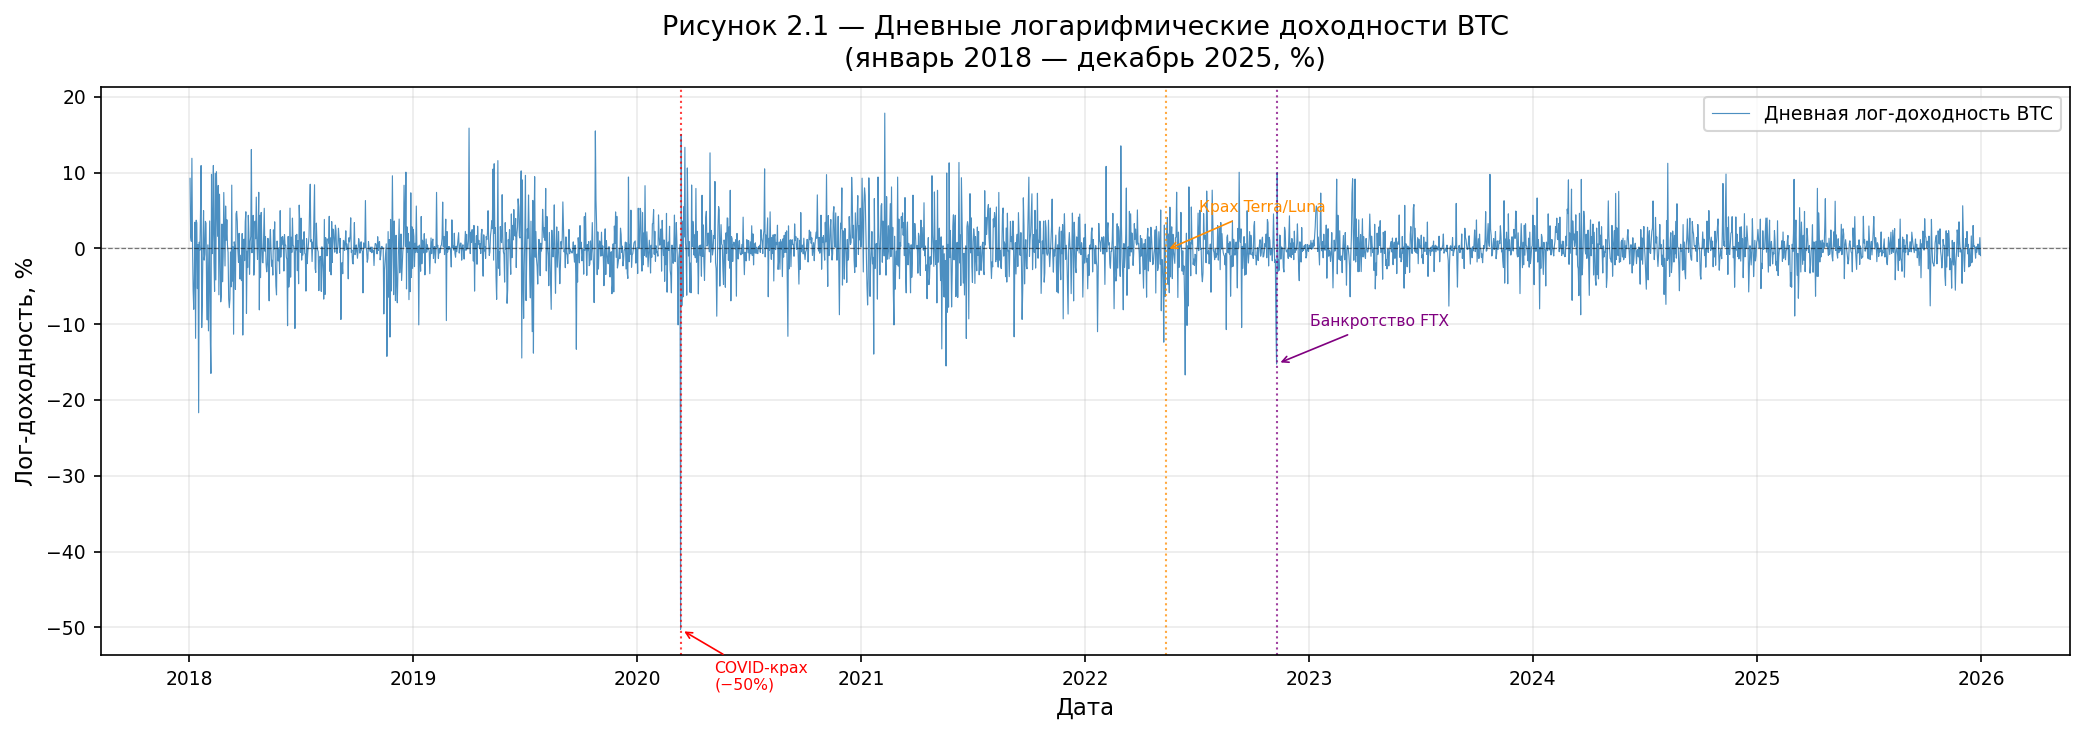

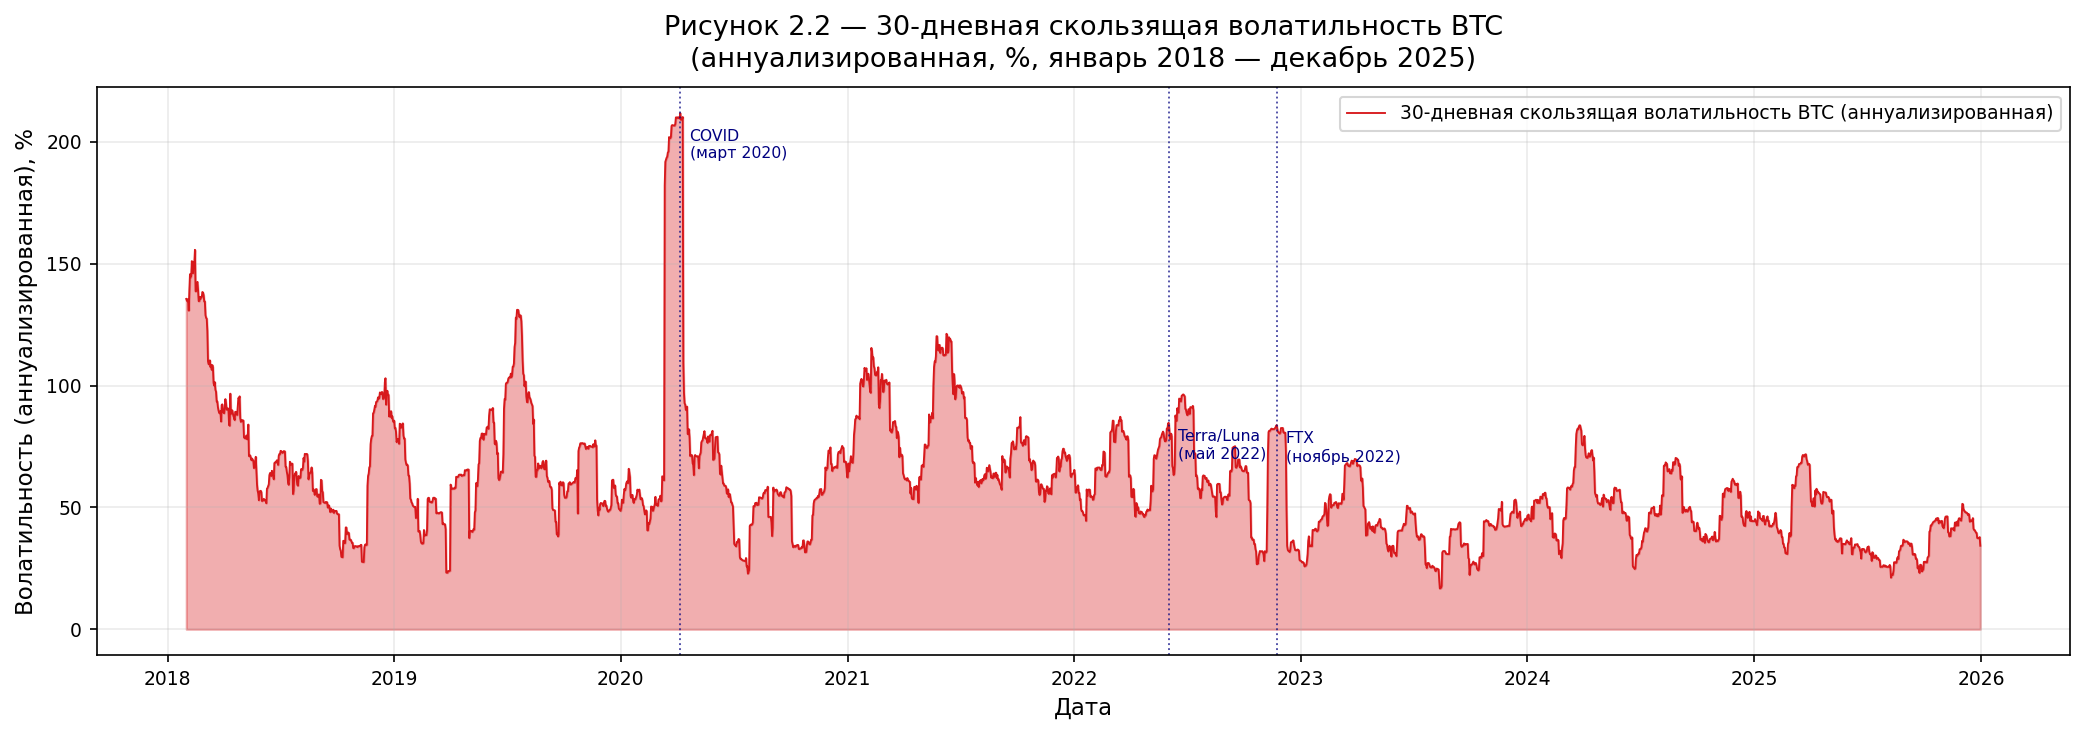

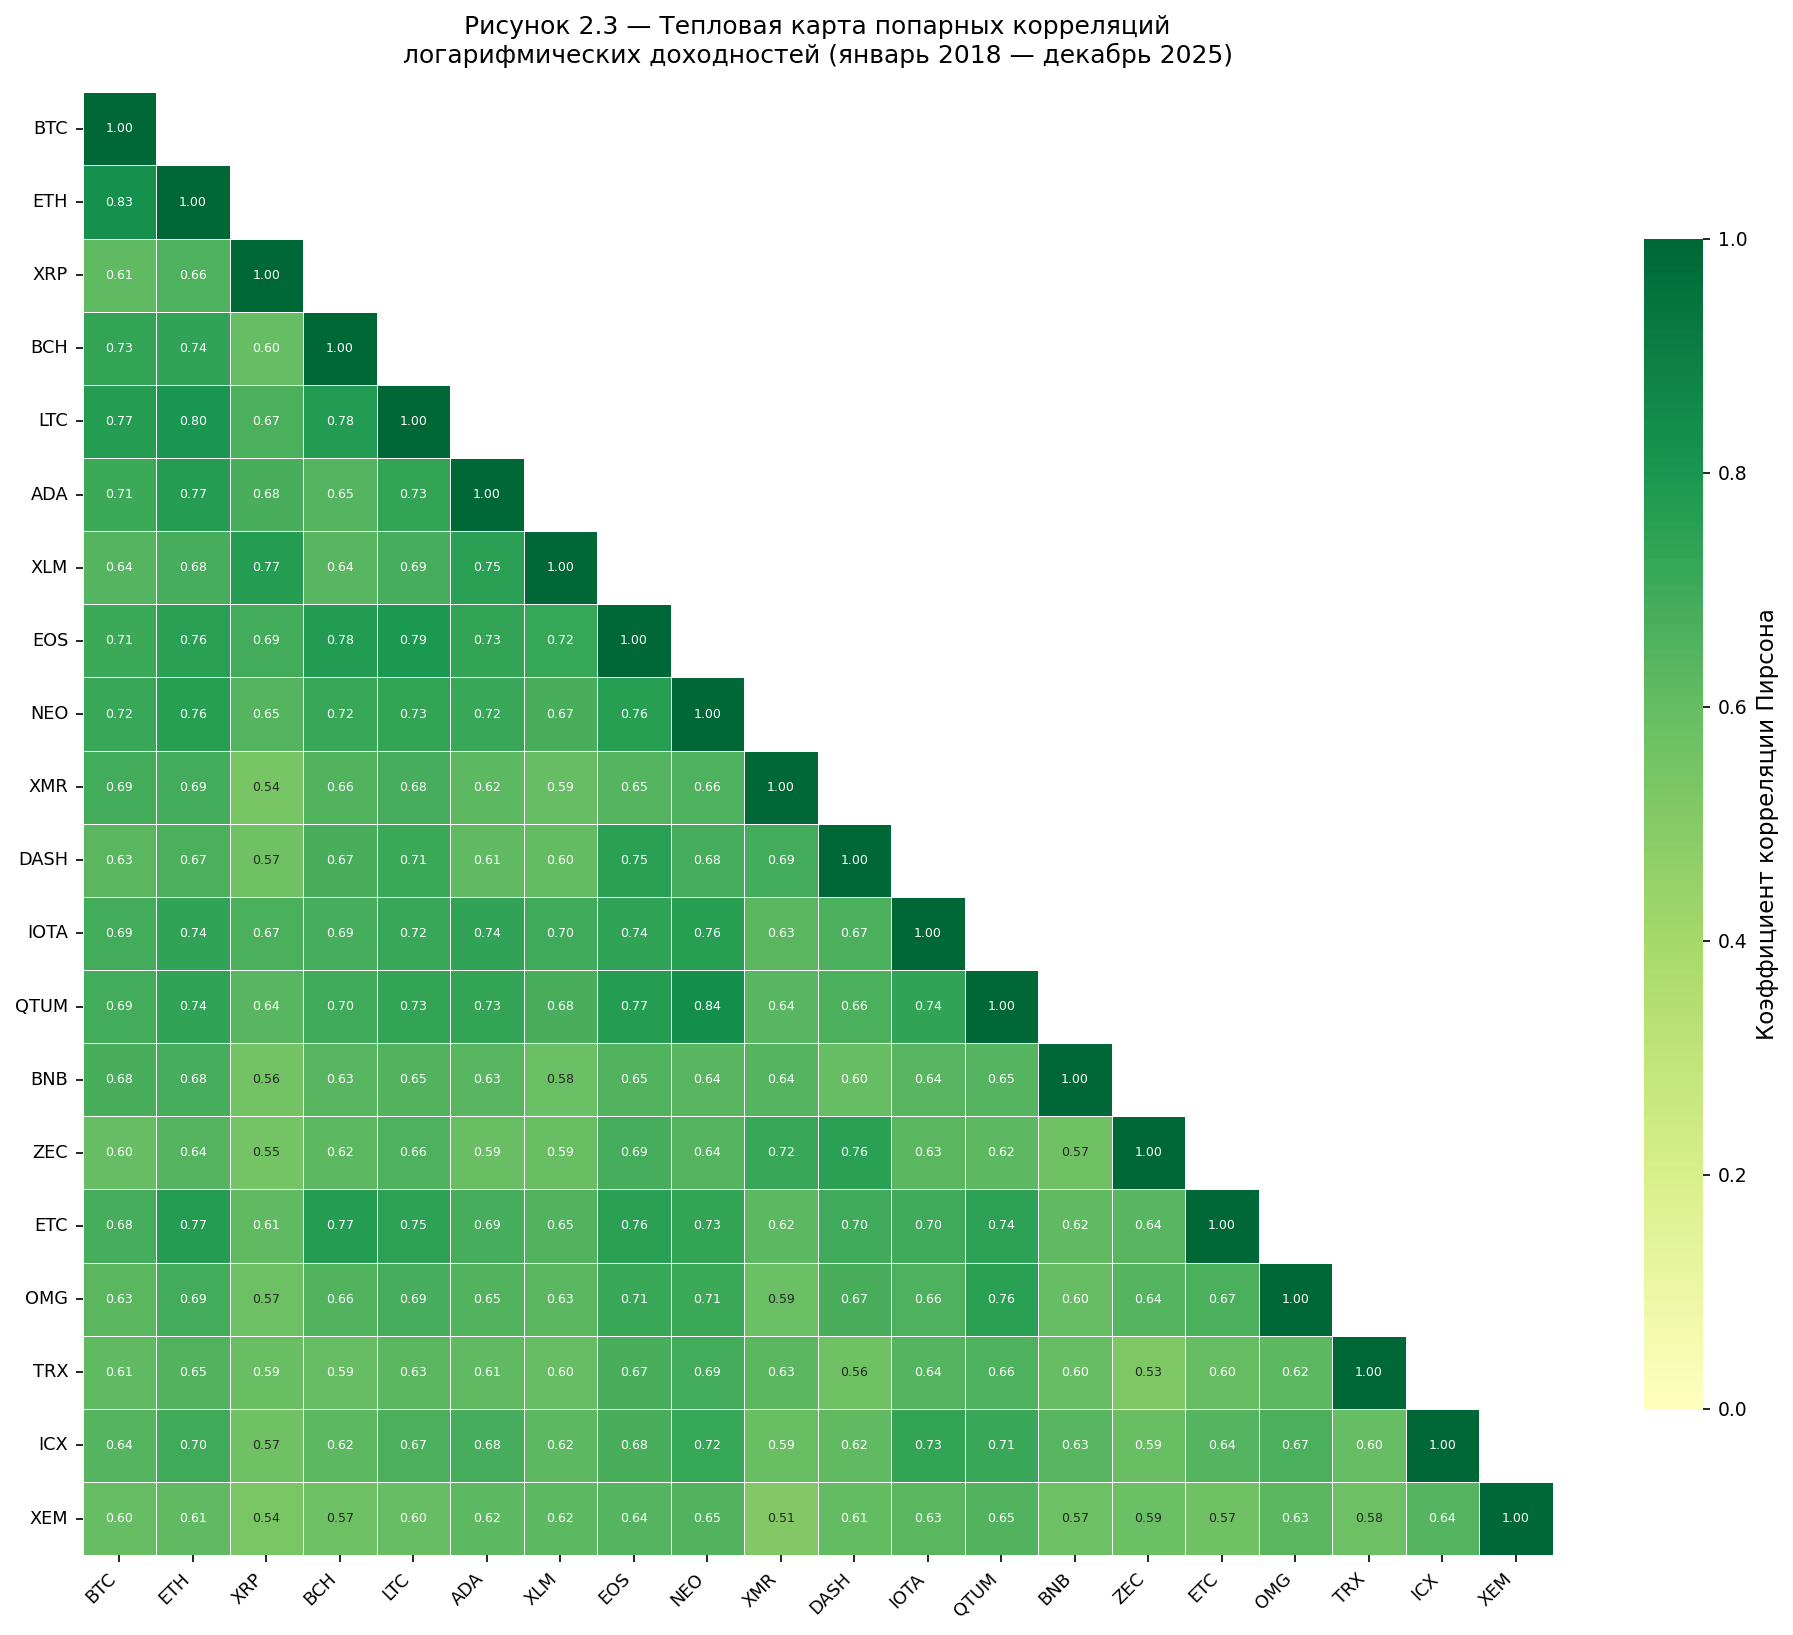


ТАБЛИЦА 5:
Актив  Среднее, %  Std, %  Min, %  Max, %  Асимметрия  Экс. эксцесс p (ЖБ) p (ЛБ) p (ARCH)
  BTC      0.0643  3.4851  -50.26   17.84      -1.149        17.798 <0.001 <0.001   <0.001
  ETH      0.0469  4.5843  -59.05   23.38      -0.955        12.772 <0.001 <0.001   <0.001
  XRP      0.0260  5.2465  -53.87   54.87       0.581        18.276 <0.001 <0.001   <0.001
  BCH      0.0456  5.1362  -61.65   46.01      -0.217        19.838 <0.001 <0.001   <0.001
  LTC     -0.0364  4.9079  -48.67   28.49      -0.605         8.997 <0.001 <0.001   <0.001
  ADA      0.0113  5.2826  -53.31   54.32       0.138        10.177 <0.001 <0.001   <0.001
  XLM     -0.0139  5.2016  -46.28   56.49       1.072        16.991 <0.001 <0.001   <0.001
  EOS     -0.1052  5.5311  -55.19   44.88      -0.641        11.322 <0.001 <0.001   <0.001
  NEO     -0.1063  5.6806  -50.24   36.90      -0.401         7.709 <0.001 <0.001   <0.001
  XMR      0.0457  4.8377  -54.70   35.27      -1.871        24.454 <0.001 <0.

In [9]:
# ==============================================================
# ПРИЛОЖЕНИЕ 1
# Программный код для формирования выборки данных,
# построения иллюстраций и расчёта описательных статистик
# Язык: Python 3.10
# Библиотеки: pandas, numpy, matplotlib, seaborn,
#             scipy, statsmodels, requests
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import time
import warnings
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

warnings.filterwarnings('ignore')

# --------------------------------------------------------------
# 1. ПАРАМЕТРЫ ВЫБОРКИ
# --------------------------------------------------------------

# Топ-20 криптовалютных пар к USDT по рыночной
# капитализации на дату начала выборки (01.01.2018)
SYMBOLS = [
    'BTCUSDT', 'ETHUSDT', 'XRPUSDT', 'BCHUSDT', 'LTCUSDT',
    'ADAUSDT', 'XLMUSDT', 'EOSUSDT', 'NEOUSDT', 'XMRUSDT',
    'DASHUSDT', 'IOTAUSDT', 'QTUMUSDT', 'BNBUSDT', 'ZECUSDT',
    'ETCUSDT', 'OMGUSDT', 'TRXUSDT', 'ICXUSDT', 'XEMUSDT'
]

START_DATE = '2018-01-01'
END_DATE   = '2025-12-31'

# --------------------------------------------------------------
# 2. ЗАГРУЗКА ДАННЫХ С BINANCE (/api/v3/klines)
# --------------------------------------------------------------

def fetch_binance_klines(symbol, interval='1d',
                         start=START_DATE, end=END_DATE):
    """
    Загрузка дневных OHLCV-данных с биржи Binance.
    Endpoint: GET /api/v3/klines
    Параметры: symbol, interval='1d', startTime, endTime
    Возвращает: pd.Series дневных цен закрытия.
    """
    url      = 'https://api.binance.com/api/v3/klines'
    start_ms = int(pd.Timestamp(start).timestamp() * 1000)
    end_ms   = int(pd.Timestamp(end).timestamp()   * 1000)
    all_rows = []

    while start_ms < end_ms:
        params = {
            'symbol':    symbol,
            'interval':  interval,
            'startTime': start_ms,
            'endTime':   end_ms,
            'limit':     1000          # максимум за один запрос
        }
        response = requests.get(url, params=params, timeout=15)
        data     = response.json()
        if not data or isinstance(data, dict):
            break
        all_rows.extend(data)
        start_ms = data[-1][0] + 1     # сдвигаем окно вперёд
        time.sleep(0.15)               # пауза для rate limit

    if not all_rows:
        return None

    df = pd.DataFrame(all_rows, columns=[
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_vol', 'trades',
        'taker_buy_base', 'taker_buy_quote', 'ignore'
    ])
    df['date']  = pd.to_datetime(df['open_time'], unit='ms')
    df['close'] = df['close'].astype(float)
    df          = df[df['close'] > 0]   # удаление технических нулей
    return df.set_index('date')['close']


# Загрузка данных по всем 20 активам
closes = {}
for sym in SYMBOLS:
    try:
        series = fetch_binance_klines(sym)
        if series is not None and len(series) > 100:
            closes[sym] = series
            print(f'  OK  {sym}  ({len(series)} дней)')
        else:
            print(f'  --  {sym}  недостаточно данных')
    except Exception as e:
        print(f'  ERR {sym}: {e}')

# Объединяем в единый DataFrame и обрезаем по периоду
closes_df = pd.DataFrame(closes).sort_index()
closes_df = closes_df.loc[START_DATE:END_DATE]

# Логарифмические доходности (формула 2.1)
# R_t = ln(P_t / P_{t-1})
# Примечание: dropna(how='all') сохраняет строки, где хотя бы
# один актив имеет данные; NaN по конкретным активам
# обрабатываются попарно при расчёте статистик
returns = np.log(closes_df / closes_df.shift(1))
returns = returns.dropna(how='all')

print(f'\nВыборка: {returns.index[0].date()} — '
      f'{returns.index[-1].date()}')
print(f'Строк: {len(returns)}, активов: {returns.shape[1]}')

# --------------------------------------------------------------
# 3. РИСУНОК 2.1
#    Дневные логарифмические доходности BTC (2018–2025)
# --------------------------------------------------------------

plt.rcParams.update({
    'font.family':   'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi':     150
})

btc_ret = returns['BTCUSDT'].dropna() * 100   # переводим в %

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(btc_ret.index, btc_ret.values,
        color='#2c7bb6', linewidth=0.55,
        alpha=0.85, label='Дневная лог-доходность BTC')
ax.axhline(0, color='black', linewidth=0.6,
           linestyle='--', alpha=0.5)

# Аннотации ключевых рыночных событий
events = {
    '2020-03-12': ('COVID-крах\n(−50%)',  'red',        'down'),
    '2022-05-12': ('Крах Terra/Luna',     'darkorange', 'up'),
    '2022-11-09': ('Банкротство FTX',     'purple',     'up'),
}
for date_str, (label, color, direction) in events.items():
    d       = pd.Timestamp(date_str)
    nearest = btc_ret.index[
        btc_ret.index.get_indexer([d], method='nearest')[0]
    ]
    val    = btc_ret[nearest]
    ax.axvline(nearest, color=color, linewidth=1.0,
               linestyle=':', alpha=0.75)
    y_text = val - 8 if direction == 'down' else val + 5
    ax.annotate(label,
                xy=(nearest, val),
                xytext=(nearest + pd.Timedelta(days=55), y_text),
                fontsize=7.5, color=color,
                arrowprops=dict(arrowstyle='->',
                                color=color, lw=0.8))

ax.set_title('Рисунок 2.1 — Дневные логарифмические доходности BTC\n'
             '(январь 2018 — декабрь 2025, %)', pad=10)
ax.set_xlabel('Дата')
ax.set_ylabel('Лог-доходность, %')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('fig_2_1_log_returns.png', dpi=300,
            bbox_inches='tight')
plt.show()

# --------------------------------------------------------------
# 4. РИСУНОК 2.2
#    30-дневная скользящая волатильность BTC (аннуализированная)
# --------------------------------------------------------------

# Суточная σ × √365 × 100 → аннуализированная волатильность в %
vol_30 = (btc_ret.rolling(30).std() * np.sqrt(365)).dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(vol_30.index, vol_30.values,
                alpha=0.35, color='#d7191c')
ax.plot(vol_30.index, vol_30.values, color='#d7191c',
        linewidth=0.9,
        label='30-дневная скользящая волатильность BTC '
              '(аннуализированная)')

# Пики волатильности в периоды рыночного стресса
peak_events = {
    '2020-03-20': 'COVID\n(март 2020)',
    '2022-05-20': 'Terra/Luna\n(май 2022)',
    '2022-11-15': 'FTX\n(ноябрь 2022)',
}
for date_str, label in peak_events.items():
    d      = pd.Timestamp(date_str)
    window = vol_30.loc[d - pd.Timedelta(days=20):
                        d + pd.Timedelta(days=20)]
    if len(window) == 0:
        continue
    peak_d = window.idxmax()
    peak_v = window.max()
    ax.axvline(peak_d, color='navy', linewidth=0.9,
               linestyle=':', alpha=0.7)
    ax.text(peak_d + pd.Timedelta(days=15),
            peak_v * 0.97,
            label, fontsize=7.5, color='navy', va='top')

ax.set_title('Рисунок 2.2 — 30-дневная скользящая волатильность BTC\n'
             '(аннуализированная, %, январь 2018 — декабрь 2025)',
             pad=10)
ax.set_xlabel('Дата')
ax.set_ylabel('Волатильность (аннуализированная), %')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('fig_2_2_volatility.png', dpi=300,
            bbox_inches='tight')
plt.show()

# --------------------------------------------------------------
# 5. РИСУНОК 2.3
#    Тепловая карта попарных корреляций доходностей 20×20
# --------------------------------------------------------------

# min_periods=100: пара учитывается при наличии
# не менее 100 совместных наблюдений
corr        = returns.corr(min_periods=100)
tick_labels = [s.replace('USDT', '') for s in corr.columns]
mask        = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',
    annot_kws={'size': 6.0},
    cmap='RdYlGn',
    center=0, vmin=0, vmax=1.0,
    linewidths=0.3, linecolor='white',
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    ax=ax,
    cbar_kws={'label': 'Коэффициент корреляции Пирсона',
              'shrink': 0.8}
)
ax.set_title('Рисунок 2.3 — Тепловая карта попарных корреляций\n'
             'логарифмических доходностей '
             '(январь 2018 — декабрь 2025)',
             fontsize=12, pad=14)
plt.xticks(rotation=45, ha='right', fontsize=8.5)
plt.yticks(rotation=0,  fontsize=8.5)

plt.tight_layout()
plt.savefig('fig_2_3_heatmap.png', dpi=300,
            bbox_inches='tight')
plt.show()

# --------------------------------------------------------------
# 6. ТАБЛИЦА 5
#    Описательные статистики логарифмических доходностей
#    по 20 активам (включая статистические тесты)
# --------------------------------------------------------------

rows = []
for sym in returns.columns:
    r     = returns[sym].dropna()
    label = sym.replace('USDT', '')

    mean_ = r.mean() * 100            # среднее, %
    std_  = r.std()  * 100            # стд. отклонение, %
    min_  = r.min()  * 100            # минимум, %
    max_  = r.max()  * 100            # максимум, %
    skew_ = stats.skew(r)             # асимметрия
    kurt_ = stats.kurtosis(r)         # избыточный эксцесс

    # Тест Жарка–Бера (H0: нормальное распределение)
    _, jb_p   = stats.jarque_bera(r)

    # Тест Льюнга–Бокса на квадратах (H0: нет автокорреляции)
    lb        = acorr_ljungbox(r**2, lags=[10], return_df=True)
    lb_p      = float(lb['lb_pvalue'].values[0])

    # Тест ARCH-LM (H0: нет ARCH-эффектов)
    try:
        _, arch_p, _, _ = het_arch(r, nlags=10)
    except Exception:
        arch_p = np.nan

    def fmt_p(p):
        if p is None or (isinstance(p, float) and np.isnan(p)):
            return 'N/A'
        return '<0.001' if p < 0.001 else str(round(p, 3))

    rows.append({
        'Актив':         label,
        'Среднее, %':    round(mean_, 4),
        'Std, %':        round(std_,  4),
        'Min, %':        round(min_,  2),
        'Max, %':        round(max_,  2),
        'Асимметрия':    round(skew_, 3),
        'Экс. эксцесс':  round(kurt_, 3),
        'p (ЖБ)':        fmt_p(jb_p),
        'p (ЛБ)':        fmt_p(lb_p),
        'p (ARCH)':      fmt_p(arch_p),
    })

table5 = pd.DataFrame(rows)
print('\nТАБЛИЦА 5:')
print(table5.to_string(index=False))

# Сохранение в CSV (открывается в Excel)
table5.to_csv('table_5_descriptive_stats.csv',
              index=False, encoding='utf-8-sig')
print('\nТаблица 5 сохранена: table_5_descriptive_stats.csv')